In [17]:
import os
import pandas as pd
from torchvision.io import read_image
import re
import wfdb
import wfdb.processing
import scipy
from torch.utils.data import Dataset
import numpy as np
import json

def extract_segment_with_padding(z, k, N):
    # Rozmiar segmentu to 2N + 1
    start_idx = k - N
    end_idx = k + N + 1  # Indeks końcowy +1, ponieważ Python używa wykluczającego indeksu
    
    # Upewnij się, że start_idx i end_idx mieszczą się w granicach tablicy
    if start_idx < 0:
        # Jeśli start_idx jest poza zakresem, dopełnij na początku
        padding_left = np.median(z[:end_idx])  # Wypełniamy medianą
        segment = np.concatenate([np.full(-start_idx, padding_left), z[:end_idx]])
    elif end_idx > len(z):
        # Jeśli end_idx jest poza zakresem, dopełnij na końcu
        padding_right = np.median(z[start_idx:])  # Wypełniamy medianą
        segment = np.concatenate([z[start_idx:], np.full(end_idx - len(z), padding_right)])
    else:
        # Normalny przypadek, kiedy zakres mieści się w tablicy
        segment = z[start_idx:end_idx]
    
    return segment

def find_nearest_qrs_index(annotation_sample, qrs_inds):
    # Find the index in qrs_inds that is closest to annotation_sample
    distances = np.abs(qrs_inds - annotation_sample)
    nearest_idx = np.argmin(distances)  # Get the index of the minimum distance
    return qrs_inds[nearest_idx]

class SHDB(Dataset):
    def __init__(self,N, M, dataset_dir = 'Datasets/temp2/shdb-af-a-japanese-holter-ecg-database-of-atrial-fibrillation-1.0.0/shdb-af-a-japanese-holter-ecg-database-of-atrial-fibrillation-1.0.0/', fs = 10):
        """
        n - number of samples of orginal signal resampled to fs, interval [-n,n]
        m - qrs times, interval [-m,m]
        """
        self.N = N
        self.ecg_list = []
        exclusion_lst = []
        for file in os.listdir(dataset_dir):
            name = re.match(r'^(.*\d\d+)\.atr$', file)
            if name:
                if name.group(1) in exclusion_lst:
                    continue
            if name:
                print(name.group(1))
                record = wfdb.rdsamp(f"{dataset_dir}{name.group(1)}") 
                annotation = wfdb.rdann(f"{dataset_dir}{name.group(1)}", 'atr')
                signal = record[0][:,0]
                fs_original = record[1]["fs"]
                num_samples_target = int(signal.shape[0] * fs / fs_original)
                resampled_signal = scipy.signal.resample(signal, num_samples_target)
                annotation_times_resampled = (annotation.sample * fs) / fs_original
                resampled_annotation = wfdb.Annotation('atr',annotation.symbol,annotation_times_resampled.astype(int),aux_note=annotation.aux_note)
                
                labels = resampled_annotation.aux_note
                segments = resampled_annotation.sample

                filtered_labels = []
                filtered_segments = []  # Start with the first segment boundary

                for i, label in enumerate(labels):
                    if label.strip():  # Include only non-empty labels
                        filtered_labels.append(label)
                        filtered_segments.append(segments[i])
                resampled_annotation.aux_note = np.array(filtered_labels)
                resampled_annotation.sample = np.array(filtered_segments)
                self.ecg_list.append({"name": name.group(1),"rec" : resampled_signal, "ann" : resampled_annotation})
            # break
        self.samples_list = []
        self.label_list = []
        self.qrs_samples = []
        self.idx_AFIB = []
        self.idx_Normal = []
        # self.label = []
        self.number_AFIB = []
        self.number_Normal = []
        no_of_afib = 0
        no_of_normal = 0
        for n,dic in enumerate(self.ecg_list):
            print(dic["name"])
            # xqrs = wfdb.processing.XQRS(sig=dic["rec"], fs=fs)
            # xqrs.detect()
            # qrs_inds = xqrs.qrs_inds
            if(len(dic["ann"].sample)==1):
                idx_next = len(dic["rec"])
            else:
                idx_next = dic["ann"].sample[1]
            label_t = dic["ann"].aux_note[0]
            temp_aux = 0
            for idx in range(dic["ann"].sample[0],len(dic["rec"]),200):
                while(idx>=idx_next):
                    temp_aux += 1
                    if(temp_aux!=len(dic["ann"].sample)-1):
                        idx_next = dic["ann"].sample[temp_aux+1]
                    else:
                        idx_next = len(dic["rec"])
                    label_t = dic["ann"].aux_note[temp_aux]
                if(label_t == '(AFIB'):
                    self.idx_AFIB.append(idx)
                    self.number_AFIB.append(n)
                else:
                    self.idx_Normal.append(idx)
                    self.number_Normal.append(n)
                if (label_t == '(AFIB'):
                    no_of_afib+=1
                else:
                    no_of_normal+=1
        self.sampled_idx_normal = np.random.choice(len(self.number_Normal), size=len(self.number_AFIB), replace=True)
    def resample(self):
        self.sampled_idx_normal = np.random.choice(len(self.number_Normal), size=len(self.number_AFIB), replace=True)
                
    def __len__(self):
        return len(self.sampled_idx_normal) + len(self.idx_AFIB)

    def __getitem__(self, idx):
        if(idx<len(self.sampled_idx_normal)):
            sample = extract_segment_with_padding(self.ecg_list[self.number_Normal[self.sampled_idx_normal[idx]]]["rec"], self.idx_Normal[self.sampled_idx_normal[idx]],self.N)
            return sample, 0
        else:
            idx = idx - len(self.sampled_idx_normal)
            sample = extract_segment_with_padding(self.ecg_list[self.number_AFIB[idx]]["rec"], self.idx_AFIB[idx],self.N)
            return sample, 1

In [18]:
ds = SHDB(100,5,fs=100)

001
002
003
004
005
006
007
008
009
010
011
012
013
014
015
016
017
018
019
020
021
022
023
024
025
026
027
028
029
030
031
032
033
034
035
036
037
038
039
040
041
042
043
045
046
047
048
049
050
051
052
054
055
056
062
064
065
070
071
073
077
084
086
102
103
105
106
107
108
109
110
111
112
113
114
115
116
117
118
122
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
001
002
003
004
005
006
007
008
009
010
011
012
013
014
015
016
017
018
019
020
021
022
023
024
025
026
027
028
029
030
031
032
033
034
035
036
037
038
039
040
041
042
043
045
046
047
048
049
050
051
052
054
055
056
062
064
065
070
071
073
077
084
086
102
103
105
106
107
108
109
110
111
112
113
114
115
116
117
118
122
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [20]:
acc_N = 0
acc_A = 0
print(len(ds.idx_AFIB)/len(ds))
for i in tqdm(range(len(ds))):
    _, label = ds[i]
    if label == 1:
        acc_A+=1
    else:
        acc_N+=1
print(acc_N, acc_A)

0.5


100%|██████████| 33537370/33537370 [00:31<00:00, 1070269.43it/s]

16768685 16768685


['(AFIB' '(N']
[    797 4855787]


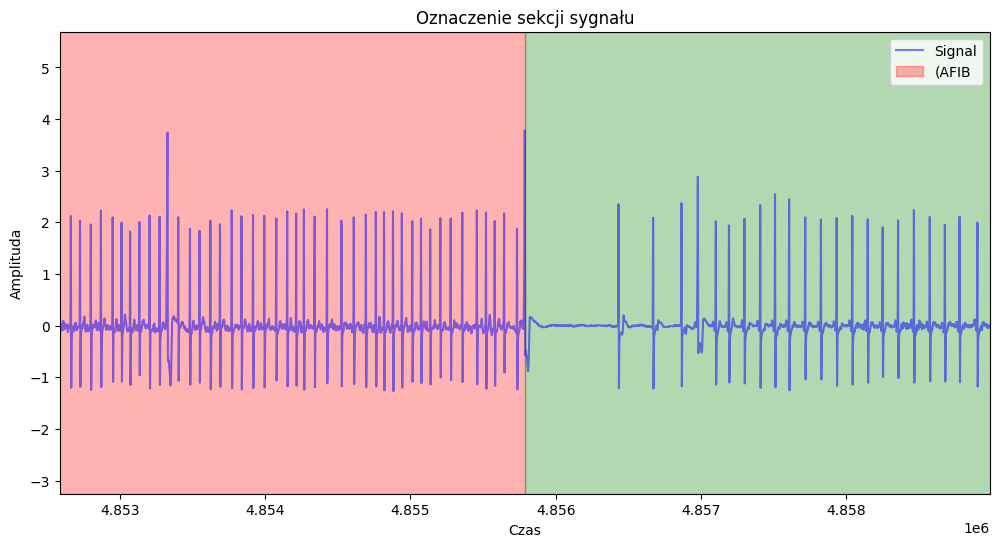

In [21]:
signal = ds.ecg_list[0]["rec"]
labels = ds.ecg_list[0]["ann"].aux_note
segments = ds.ecg_list[0]["ann"].sample
# Kolory przypisane do etykiet
color_map = {
    '(N': 'green',
    '(AFIB': 'red',
    'other': 'yellow'
}

# Rysowanie wykresu
plt.figure(figsize=(12, 6))
plt.plot(signal, color='blue', alpha=0.5, label='Signal')

# Iteracja przez segmenty
for i in range(len(labels)):
    start = segments[i]
    if(len(segments) != i + 1):
        end = segments[i + 1]
    else:
        end = len(signal)
    label = labels[i]
    
    # Przypisanie koloru
    color = color_map.get(label, 'yellow')  # Domyślny kolor to 'yellow'
    
    # Podświetlenie segmentu
    plt.axvspan(start, end, color=color, alpha=0.3, label=f'{label}' if i == 0 else "")
print(labels)
print(segments)
# Dodatkowe elementy wykresu
plt.title('Oznaczenie sekcji sygnału')
plt.xlabel('Czas')
plt.ylabel('Amplituda')
plt.legend(loc='upper right')
plt.xlim([4855787-3200,4855787+3200])
plt.show()